<a href="https://colab.research.google.com/github/xMrTuffnut/ai-companion-wellbeing/blob/main/notebooks/01_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing
**Owner: Person A**

Rules: only the owner edits this notebook. Before saving to GitHub: *Runtime → Restart and run all*.

In [1]:
# ---- Shared setup cell: same in every notebook, don't change it alone ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

# Raw data (original study). Once data/clean.csv exists, switch to CLEAN_URL.
RAW_URL = "https://raw.githubusercontent.com/SALT-NLP/AI-companionship-well-being/main/data.csv"
CLEAN_URL = "https://raw.githubusercontent.com/xMrTuffnut/ai-companion-wellbeing/main/data/clean.csv"

df = pd.read_csv(RAW_URL)
print(df.shape)

(1131, 14)


In [2]:
# Save a figure and download it (then upload it to figures/ on GitHub)
def save_fig(name):
    plt.savefig(name, dpi=200, bbox_inches="tight")
    try:
        from google.colab import files
        files.download(name)
    except ImportError:
        pass  # not in Colab: file is saved next to the notebook

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1131 entries, 0 to 1130
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   participant_id        1131 non-null   object 
 1   well_being            1131 non-null   float64
 2   intensity             1131 non-null   float64
 3   companionship_prim    1131 non-null   int64  
 4   companionship_desc    1131 non-null   int64  
 5   companionship_chat    237 non-null    float64
 6   self_disclosure       1131 non-null   float64
 7   social_network_scale  1131 non-null   float64
 8   tenure_of_activity    1131 non-null   float64
 9   donated               1131 non-null   int64  
 10  male                  1131 non-null   int64  
 11  non_binary            1131 non-null   int64  
 12  age                   1131 non-null   int64  
 13  single                1131 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 123.8+ KB


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
well_being,1131.0,4.79,1.33,1.00,3.92,5.00,5.83,7.00
intensity,1131.0,0.00,1.00,-2.56,-0.70,0.16,0.80,1.91
companionship_prim,1131.0,0.12,0.32,0.00,0.00,0.00,0.00,1.00
companionship_desc,1131.0,0.51,0.50,0.00,0.00,1.00,1.00,1.00
companionship_chat,237.0,-0.02,1.00,-1.60,-0.71,0.04,0.76,1.44
self_disclosure,1131.0,-0.00,1.00,-3.23,-0.51,0.17,0.73,1.52
social_network_scale,1131.0,0.00,1.00,-1.89,-0.88,0.14,0.64,3.17
tenure_of_activity,1131.0,-0.00,1.00,-1.82,-0.46,-0.46,0.90,0.90
donated,1131.0,0.21,0.41,0.00,0.00,0.00,0.00,1.00
male,1131.0,0.48,0.50,0.00,0.00,0.00,1.00,1.00


In [5]:
df.isna().sum()

,0
participant_id,0
well_being,0
intensity,0
companionship_prim,0
companionship_desc,0
companionship_chat,894
self_disclosure,0
social_network_scale,0
tenure_of_activity,0
donated,0


  ## Cleaning
   **Step 1: Duplicates.** Each participant should appear only once, so we check participant_id for duplicates.

In [6]:
print("Duplicate participants:", df["participant_id"].duplicated().sum())

Duplicate participants: 0


   **Step 2: Drop companionship_chat.** This column only has values for the 237 participants who donated their chat logs (894 missing). The values are missing by design, not at random. Filling them in would invent data, and dropping those rows would remove 79% of the sample, so we drop the column instead.

In [7]:
df = df.drop(columns="companionship_chat")
print(df.shape)

(1131, 13)


   **Step 3: Age outliers.** We check age with the IQR rule: values above Q3 + 1.5 × IQR count as statistical outliers. 43 participants are older than 55.5. We keep them, because they are real users and not data errors. Removing them would make an already young sample even younger.

count    1131.000000
mean       30.675508
std        11.091251
min        18.000000
25%        23.000000
50%        27.000000
75%        36.000000
max        90.000000
Name: age, dtype: float64
IQR: 13.0, upper limit: 55.5
Participants above the limit: 43


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

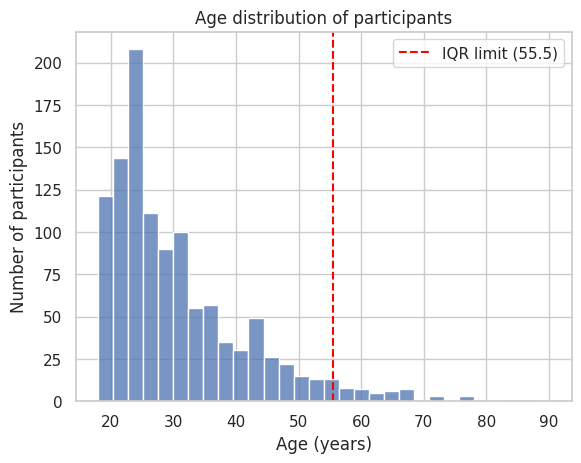

In [8]:
print(df["age"].describe())

q1, q3 = df["age"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"IQR: {iqr}, upper limit: {upper}")
print("Participants above the limit:", (df["age"] > upper).sum())

sns.histplot(df["age"], bins=30)
plt.axvline(upper, color="red", linestyle="--", label=f"IQR limit ({upper})")
plt.xlabel("Age (years)")
plt.ylabel("Number of participants")
plt.title("Age distribution of participants")
plt.legend()
save_fig("age_distribution.png")
plt.show()

   **Step 4: Readable labels.** The original columns use 0/1 codes and standardized scores, which are hard to read in plots. We add four label columns for plots and tables; the original columns stay unchanged for the statistical tests.
   - age_group: age in four groups
   - gender: built from male and non_binary (neither = female, to be confirmed in the paper)
   - companion_group: built from companionship_prim
   - tenure_group: tenure_of_activity has only 3 distinct values, so it is really 3 groups (1 = shortest, 3 = longest use)

In [9]:
df["age_group"] = pd.cut(df["age"], bins=[17, 24, 34, 44, 120],
                            labels=["18-24", "25-34", "35-44", "45+"])

df["gender"] = np.select([df["male"] == 1, df["non_binary"] == 1],
                            ["male", "non-binary"], default="female")

df["companion_group"] = np.where(df["companionship_prim"] == 1,
                                    "Companion (primary use)", "Other use")

df["tenure_group"] = df["tenure_of_activity"].rank(method="dense").astype(int)

for col in ["age_group", "gender", "companion_group", "tenure_group"]:
       print(df[col].value_counts(), "\n")

age_group
25-34    419
18-24    410
35-44    171
45+      131
Name: count, dtype: int64 

gender
male          548
female        525
non-binary     58
Name: count, dtype: int64 

companion_group
Other use                  997
Companion (primary use)    134
Name: count, dtype: int64 

tenure_group
3    564
2    388
1    179
Name: count, dtype: int64 



   **Step 5: Final check.** The cleaned dataset has 1,131 participants and 17 columns (14 original − 1 dropped + 4 new label columns). It is saved as data/clean.csv and used by all other notebooks.

In [10]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1131 entries, 0 to 1130
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   participant_id        1131 non-null   object  
 1   well_being            1131 non-null   float64 
 2   intensity             1131 non-null   float64 
 3   companionship_prim    1131 non-null   int64   
 4   companionship_desc    1131 non-null   int64   
 5   self_disclosure       1131 non-null   float64 
 6   social_network_scale  1131 non-null   float64 
 7   tenure_of_activity    1131 non-null   float64 
 8   donated               1131 non-null   int64   
 9   male                  1131 non-null   int64   
 10  non_binary            1131 non-null   int64   
 11  age                   1131 non-null   int64   
 12  single                1131 non-null   int64   
 13  age_group             1131 non-null   category
 14  gender                1131 non-null   object  
 15  comp

,participant_id,well_being,intensity,companionship_prim,companionship_desc,self_disclosure,social_network_scale,tenure_of_activity,donated,male,non_binary,age,single,age_group,gender,companion_group,tenure_group
0,P001,5.500000,-0.726215,0,0,-0.058645,0.641817,-1.821462,0,0,0,28,0,25-34,female,Other use,1
1,P002,1.833333,-1.437133,0,1,0.506863,-0.875530,-0.462575,1,0,0,36,1,35-44,female,Other use,2
2,P003,5.500000,0.529299,0,0,0.506863,1.147600,0.896313,0,0,0,48,0,45+,female,Other use,3
3,P004,4.500000,-0.637609,1,1,0.393761,-1.381312,-0.462575,0,1,0,53,0,45+,male,Companion (primary use),2
4,P005,3.333333,-0.738990,0,0,-0.511052,-0.875530,0.896313,0,1,0,28,1,25-34,male,Other use,3


In [11]:
# Save the cleaned data and download it, then upload it to data/ on GitHub
clean = df.copy()
clean.to_csv("clean.csv", index=False)
try:
    from google.colab import files
    files.download("clean.csv")
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>